In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table

In [2]:
dp_samples = fits.open('sample_catalog.fits')
dp_samples.info()

Filename: sample_catalog.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  DATA          1 BinTableHDU     53   2211R x 22C   [K, E, E, E, E, E, E, E, E, E, E, E, L, L, L, L, L, L, L, L, L, L]   
  2  1COMP         1 ImageHDU         8   (7781, 2211)   float64   
  3  2COMP_L       1 ImageHDU         8   (7781, 2211)   float64   
  4  2COMP_R       1 ImageHDU         8   (7781, 2211)   float64   


In [3]:
samples_df = Table(dp_samples[1].data).to_pandas()

In [4]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

FIT = FitSpectrum()
DP_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=samples_df['TARGETID'].to_list())
DP_SPECTRA = DP_SPECTRA.stack_data()
DP_SPECTRA = DP_SPECTRA.shift_to_rest_frame()
DP_SPECTRA = FIT.label_emission_lines(DP_SPECTRA, 3)

In [5]:
model_1comp = dp_samples[2].data
model_2comp_l = dp_samples[3].data
model_2comp_r = dp_samples[4].data

In [11]:
test_idx = 100
test_1comp = model_1comp[test_idx]
test_2comp_l = model_2comp_l[test_idx]
test_2comp_r = model_2comp_r[test_idx]
test_2comp = test_2comp_l + test_2comp_r


lam, flux, ivar = DP_SPECTRA.data_stack[test_idx, 0, :], DP_SPECTRA.data_stack[test_idx, 1, :], DP_SPECTRA.data_stack[test_idx, 2, :]
emission = DP_SPECTRA.data_stack[test_idx, 5, :]
sigma = 1/np.sqrt(np.abs(ivar))

/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_12073/2678477076.py:10: RuntimeWarning: divide by zero encountered in divide
  sigma = 1/np.sqrt(np.abs(ivar))


In [12]:
samples_df.head(10)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,OII3726_dp,OII3729_dp,Hbeta_dp,OIII4959_dp,OIII5007_dp,NII6548_dp,Halpha_dp,NII6583_dp,SII6716_dp,SII6731_dp
0,39627739388446085,177.553467,-1.885023,0.175950,10.330100,-0.883781,79.954552,-48.104931,37.027283,26.972086,...,False,False,False,False,False,False,True,True,False,False
1,39627739396834813,178.063049,-1.962034,0.164261,9.924163,0.011910,20.608299,-124.347061,68.387367,0.010000,...,False,False,False,False,False,False,True,False,False,False
2,39627739401029921,178.353241,-1.887325,0.233979,10.177996,-0.036541,63.975224,-33.530704,59.500328,35.649895,...,False,False,False,False,False,False,True,False,False,False
3,39627739417806469,179.316284,-1.905162,0.139728,10.346331,-13.826033,55.173431,-107.414040,74.724747,25.010038,...,False,False,False,False,False,False,True,False,False,False
4,39627739417810509,179.477615,-1.980264,0.141863,9.811453,-1.073316,78.578522,-16.143122,0.010000,44.215126,...,False,False,False,False,False,False,True,False,False,False
5,39627739426194883,179.801468,-1.903916,0.228588,10.014006,0.907092,59.511105,-40.775631,34.817703,38.134174,...,False,False,False,False,False,False,True,True,False,False
6,39627739442971930,180.787811,-1.951623,0.154830,10.032695,0.908490,28.527670,-75.283386,41.750584,26.149443,...,False,False,False,False,False,False,True,True,False,False
7,39627739451359377,181.254425,-1.984311,0.082309,10.573962,1.109863,58.129417,-79.988899,50.418571,51.029903,...,False,False,True,False,False,False,True,True,False,False
8,39627739451365481,181.474350,-1.903744,0.252780,10.398445,-0.019321,73.831703,-84.630592,29.876556,51.659870,...,False,False,False,False,False,False,True,False,False,False
9,39627739459752218,181.914886,-1.896473,0.156940,10.010163,0.784921,59.791534,-47.830563,40.169281,46.782898,...,False,True,False,False,False,False,True,False,False,False


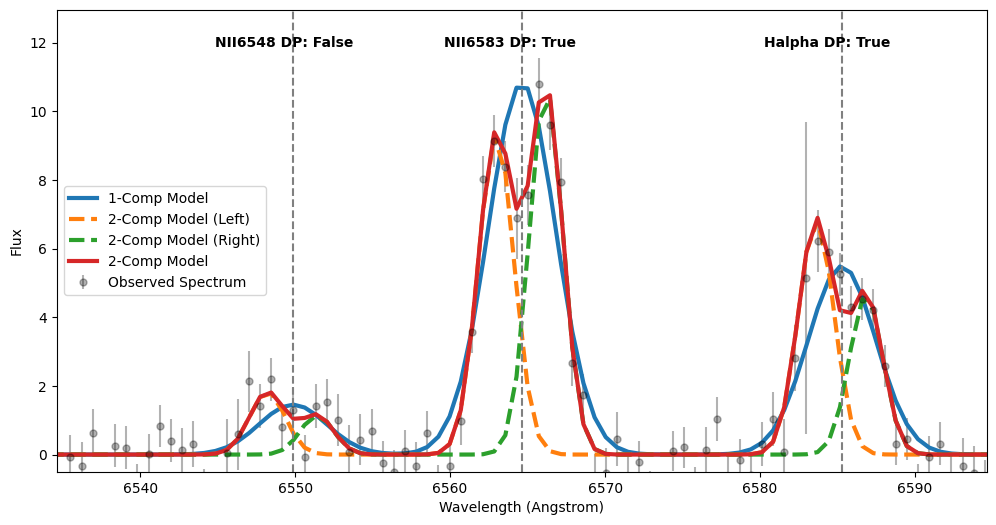

In [16]:
line_cols = ['OII3726', 'OII3729',
            'Hbeta',
            'OIII4959', 'OIII5007',
            'NII6548', 'Halpha', 'NII6583',
            'SII6716', 'SII6731']
lines = [*OII_rest, *Hbeta_rest, *OIII_rest, *NII_rest, *Halpha_rest, *SII_rest]

plt.figure(figsize=(12,6))
plt.errorbar(lam, flux, yerr=sigma, label='Observed Spectrum', fmt='o', color='k', markersize=5, alpha=0.3)
plt.plot(lam, test_1comp, label='1-Comp Model', linewidth=3)
plt.plot(lam, test_2comp_l, label='2-Comp Model (Left)', linestyle='--', linewidth=3)
plt.plot(lam, test_2comp_r, label='2-Comp Model (Right)', linestyle='--', linewidth=3)
plt.plot(lam, test_2comp, label='2-Comp Model', linewidth=3)
# plt.plot(lam, emission, label='Emission Line Only', color='orange', alpha=0.7)
# plt.plot(lam, 3*sigma, label=r'3$\sigma$ Limit', color='red', linestyle='--')
# plt.text(6550, 10, 'test', rotation=90, color='gray', fontsize=8)
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Flux')
plt.xlim([Halpha_rest[0]-30, Halpha_rest[0]+30])
# plt.xlim([OII_rest[0]-30, OII_rest[1]+30])
# plt.xlim([OIII_rest[0]-30, OIII_rest[1]+30])
plt.ylim(bottom=-0.5, top=np.max(flux[(lam>plt.xlim()[0]) & (lam<plt.xlim()[1])])*1.2)

for i, line in enumerate(lines):
    if line < plt.xlim()[0] or line > plt.xlim()[1]:
        continue
    else:
        plt.axvline(x=line, color='gray', linestyle='--')
        line_label = f'{line_cols[i]} DP: {samples_df[line_cols[i]+'_dp'].iloc[test_idx]}'
        plt.text(line-5, np.max(flux[(lam>plt.xlim()[0]) & (lam<plt.xlim()[1])])*1.1, line_label, color='k', fontsize=10, weight='bold')
plt.legend()
plt.show()